<a href="https://www.kaggle.com/code/salmix1326/nn-homework2-3-4?scriptVersionId=294448018" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
import torch
from torchvision import datasets, transforms

In [5]:
# создание датасетов
data_all = "/kaggle/input/fruit-recognition/train/train"
dataset = datasets.ImageFolder(data_all)

In [6]:
# деление данных с перемешиванием
data_train, data_test = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [7]:
# трансформеры картинок
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(10),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [8]:
# создание классов для обработки картинок через трансформеры
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [43]:
# обработка датасетов через трансформеры
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

3370

In [ ]:
# сетка для проверки трансформированных картинок
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [10]:
# подготовка пакетов картинок для нейросети
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [11]:
from torch import nn

# Архитектура нейронной сети
# Вариант 1: Полносвязная (MLP)
# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(12288, 256),
#     nn.ReLU(),
#     nn.Linear(256, 128),
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)
# )

# device = "cuda"
# model = model.to(device)

# Вариант 2: Свёрточная нейронная сеть (CNN)
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding="same"), # 8, 64, 64
    nn.ReLU(), # 8, 64, 64
    nn.MaxPool2d(2, 2), # 8, 32, 32
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding="same"), # 16, 32, 32
    nn.ReLU(), # 16, 32, 32
    nn.MaxPool2d(2, 2), # 16, 16, 16
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding="same"), # 32, 16, 16
    nn.ReLU(), # 32, 16, 16
    nn.MaxPool2d(2, 2), # 32, 8, 8
    
    nn.Flatten(),
    nn.Linear(32*8*8, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)
)

device = "cuda"
model = model.to(device)

In [28]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.02
)

loss_list = []
loss_test_list = []

for i in range(1):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"test loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.495905637741089
loss: 3.4856839179992676
loss: 3.4863743782043457
loss: 3.472987174987793
loss: 3.4737775325775146
loss: 3.441469192504883
loss: 3.434877872467041
loss: 3.3976855278015137
loss: 3.380110740661621
loss: 3.21120023727417
loss: 3.1406407356262207
loss: 3.203432083129883
loss: 3.1253836154937744
loss: 3.204468011856079
loss: 3.115518093109131
loss: 3.1759305000305176
loss: 3.0752735137939453
loss: 3.140188694000244
loss: 3.0528407096862793
loss: 3.044706344604492
loss: 3.0272397994995117
loss: 3.061378240585327
loss: 2.9456229209899902
loss: 3.0201261043548584
loss: 2.985813856124878
loss: 3.012702703475952
loss: 2.9582481384277344
loss: 3.0443625450134277
loss: 2.9147162437438965
loss: 2.944115161895752
loss: 2.88529634475708
loss: 2.864680290222168
loss: 2.9138989448547363
loss: 2.88303542137146
loss: 2.8773250579833984
loss: 2.8403573036193848
loss: 2.7538063526153564
loss: 2.8703322410583496
loss: 2.7847890853881836
loss: 2.7490673065185547
loss: 2.6695704460144

In [56]:
# проверка точности тренировочных/тестовых данных после обработки в нейросети
import math
true_count = 0

for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)

    res = model(imgs)
    res = res.argmax(dim=1)
    true_sum = sum(res == labels)
    true_count += true_sum.cpu().item()

procent = math.ceil((true_count/len(train_data))*100)
print(f"Accuracy procent: {procent}%")

Accuracy procent: 17%


In [ ]:
# настройки графика
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

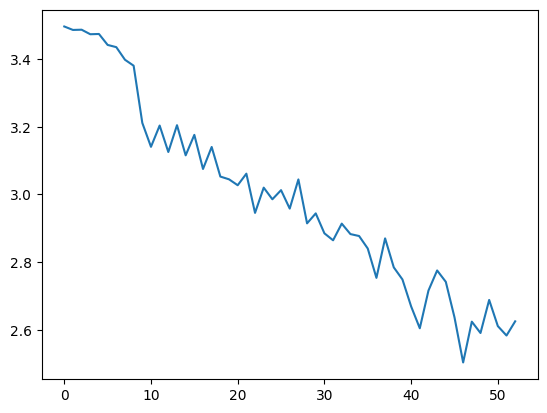

In [29]:
# график для ошибок тренировочных данных после обработки нейросети
import matplotlib.pyplot as plt
plt.plot(loss_list)

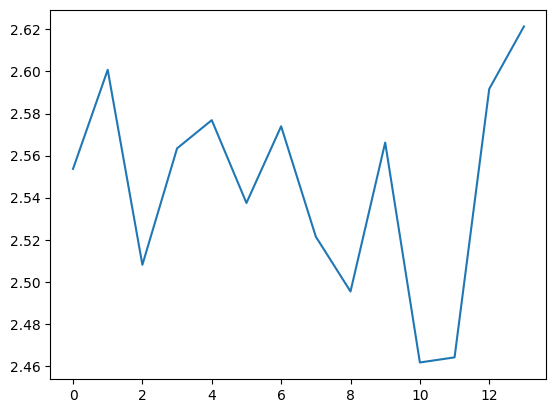

In [30]:
# график для ошибок тестовых данных после обработки нейросети
plt.plot(loss_test_list)